In [17]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("data/alpha.csv")
print(df.head())

          name  steps  dimension     alpha
0  Hubbard 2x3      4          7   63.0000
1  Hubbard 3x3      1          5  180.0000
2  Hubbard 4x3      2         10  240.0000
3     hchain 2      8          5    0.2105


In [19]:
# Fit linear regressions to dimension vs. alpha and steps vs. alpha
steps_result = linregress(df["alpha"], df["steps"])
print(steps_result.rvalue, steps_result.pvalue)
dimension_result = linregress(df["alpha"], df["dimension"])
print(dimension_result.rvalue, dimension_result.pvalue)

# Get data that we can plot.
fit_alpha = np.linspace(np.min(df["alpha"]), np.max(df["alpha"]))
steps_fit_y = steps_result.slope * fit_alpha + steps_result.intercept
dimension_fit_y = dimension_result.slope * fit_alpha + dimension_result.intercept

-0.8880327190676675 0.11196728093233253
0.6221265024115542 0.3778734975884458


In [26]:
system_types = ["Hubbard", "hchain"]

Text(0.5, 0, '$\\alpha$')

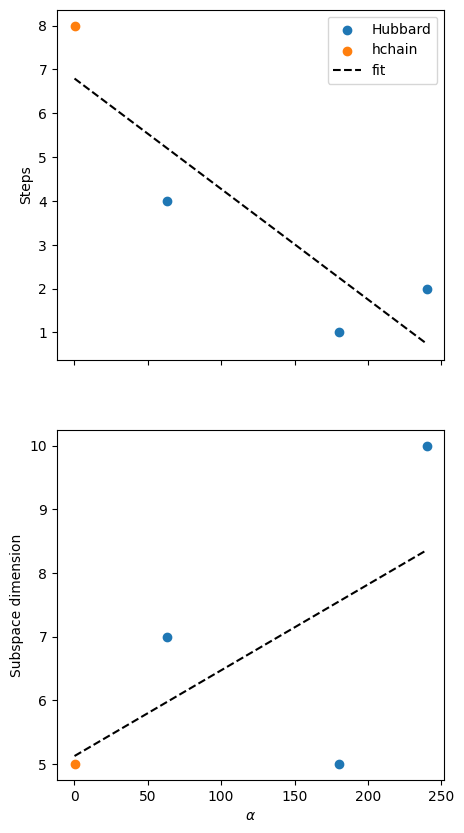

In [28]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(5, 10))
for type in system_types:
    df_type = df[df["name"].str.contains(type)]
    assert len(df_type) != 0
    ax[0].scatter(df_type["alpha"], df_type["steps"], label=type)
ax[0].plot(fit_alpha, steps_fit_y, linestyle="--", color="k", label="fit")
ax[0].set_ylabel("Steps")
ax[0].legend()
for type in system_types:
    df_type = df[df["name"].str.contains(type)]
    assert len(df_type) != 0
    ax[1].scatter(df_type["alpha"], df_type["dimension"], label=type)
ax[1].plot(fit_alpha, dimension_fit_y, linestyle="--", color="k")
ax[1].set_ylabel("Subspace dimension")
ax[1].set_xlabel(r"$\alpha$")